In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
from google.colab import files
uploaded = files.upload()

Saving matches.csv to matches.csv


In [5]:
df = pd.read_csv("matches.csv")
df.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [6]:
print("Total Matches: ", df.shape[0])
print("Total Columns: ", df.shape[1])
print("\nColumn Names:\n", df.columns.tolist())
print("\nMissing Values:\n", df.isnull().sum())

Total Matches:  1095
Total Columns:  20

Column Names:
 ['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']

Missing Values:
 id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64


In [8]:
#Clean missing values
df['city'].fillna('Unknown', inplace=True)
df.dropna(subset=['winner'], inplace=True)

print("Cleaned! Remaining matches:", df.shape[0])


Cleaned! Remaining matches: 1090


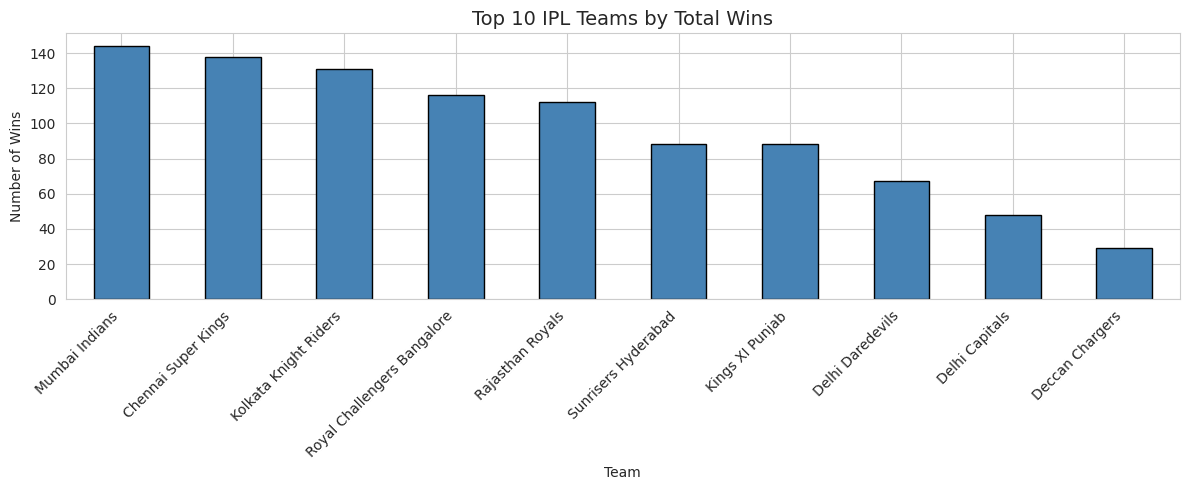

In [9]:
plt.figure(figsize=(12,5))
df['winner'].value_counts().head(10).plot(kind='bar', color='steelblue', edgecolor='black')
plt.title("Top 10 IPL Teams by Total Wins", fontsize=14)
plt.xlabel("Team")
plt.ylabel("Number of Wins")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

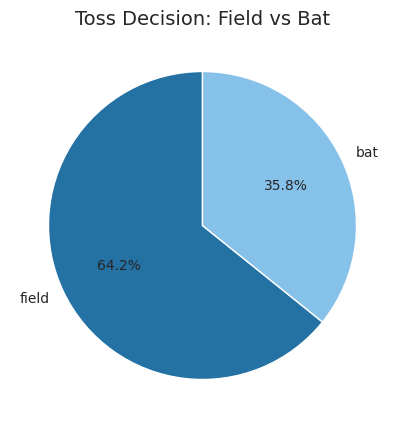

In [10]:
plt.figure(figsize=(6,5))
df['toss_decision'].value_counts().plot(
    kind='pie', autopct='%1.1f%%',
    colors=['#2471A3','#85C1E9'],
    startangle=90
)
plt.title("Toss Decision: Field vs Bat", fontsize=14)
plt.ylabel("")
plt.show()

Toss winner also won the match:
toss_match_win
True     554
False    536
Name: count, dtype: int64


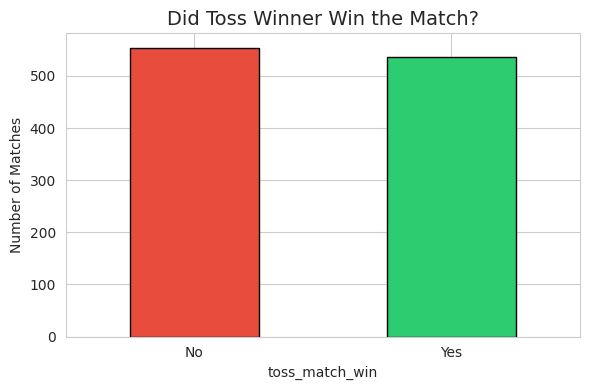

In [11]:
df['toss_match_win'] = df['toss_winner'] == df['winner']
print("Toss winner also won the match:")
print(df['toss_match_win'].value_counts())

plt.figure(figsize=(6,4))
df['toss_match_win'].value_counts().plot(kind='bar', color=['#E74C3C','#2ECC71'], edgecolor='black')
plt.title("Did Toss Winner Win the Match?", fontsize=14)
plt.xticks([0,1], ['No','Yes'], rotation=0)
plt.ylabel("Number of Matches")
plt.tight_layout()
plt.show()

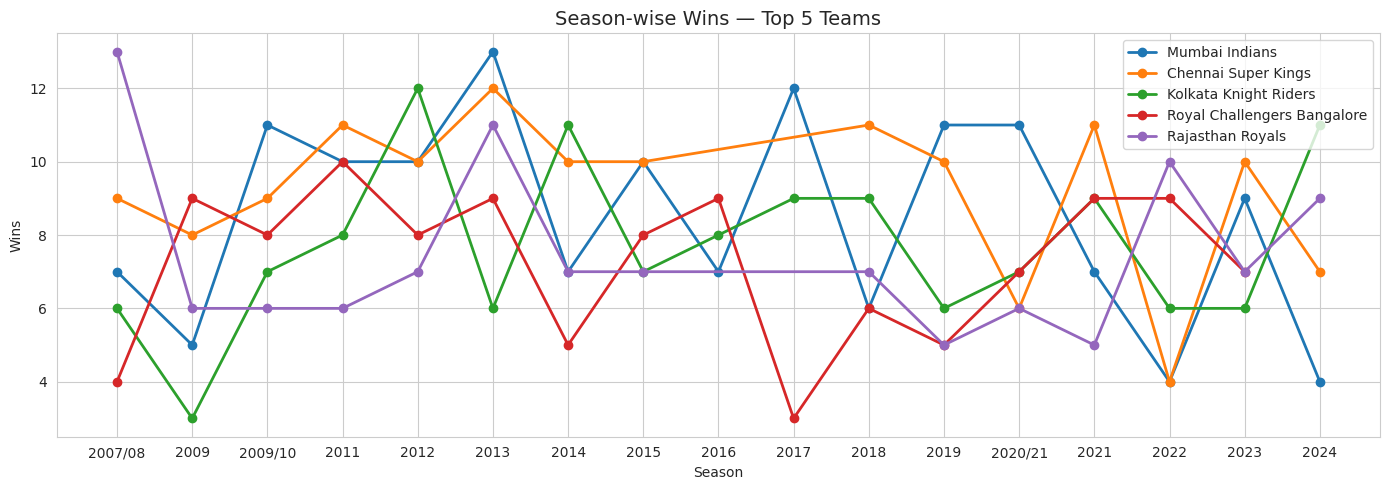

In [12]:
top_teams = df['winner'].value_counts().head(5).index
season_data = df[df['winner'].isin(top_teams)]
season_wins = season_data.groupby(['season','winner']).size().reset_index(name='wins')

plt.figure(figsize=(14,5))
for team in top_teams:
    data = season_wins[season_wins['winner'] == team]
    plt.plot(data['season'], data['wins'], marker='o', linewidth=2, label=team)

plt.title("Season-wise Wins — Top 5 Teams", fontsize=14)
plt.xlabel("Season")
plt.ylabel("Wins")
plt.legend()
plt.tight_layout()
plt.show()

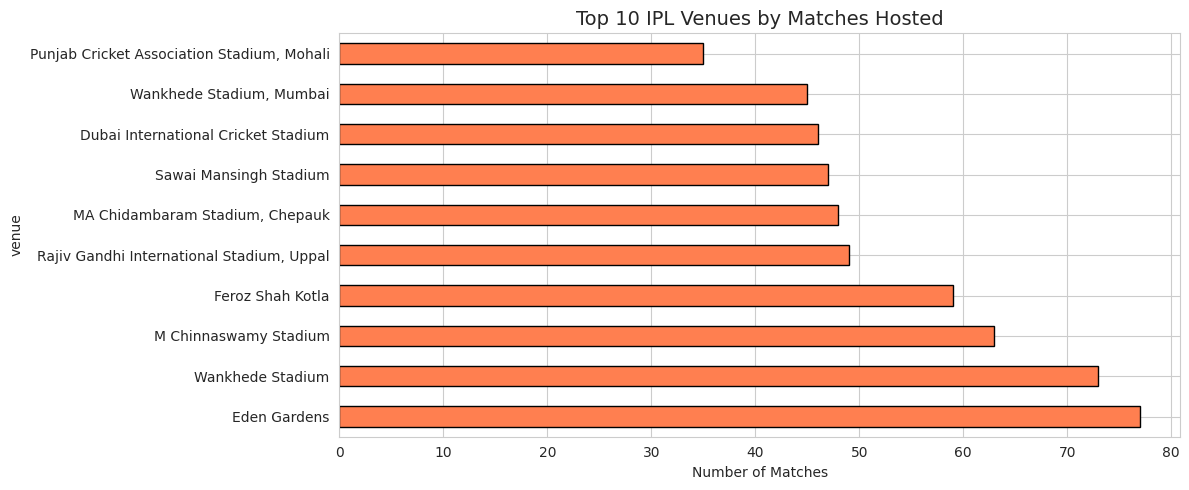

In [13]:
plt.figure(figsize=(12,5))
df['venue'].value_counts().head(10).plot(
    kind='barh', color='coral', edgecolor='black')
plt.title("Top 10 IPL Venues by Matches Hosted", fontsize=14)
plt.xlabel("Number of Matches")
plt.tight_layout()
plt.show()

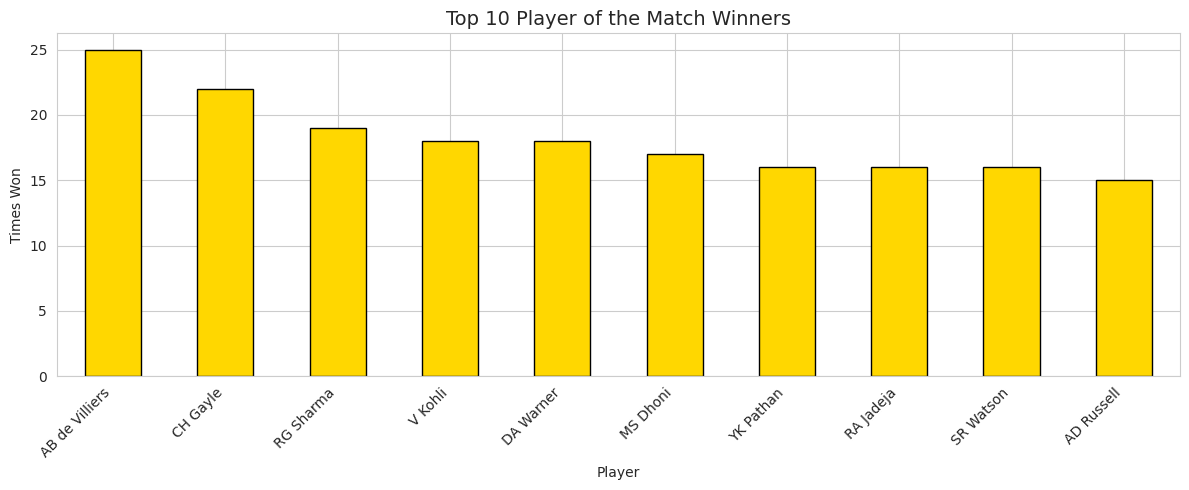

In [14]:
plt.figure(figsize=(12,5))
df['player_of_match'].value_counts().head(10).plot(
    kind='bar', color='gold', edgecolor='black')
plt.title("Top 10 Player of the Match Winners", fontsize=14)
plt.xlabel("Player")
plt.ylabel("Times Won")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## IPL Data Analysis (2008-2024) — Key Findings

- **Mumbai Indians** are the most successful IPL team with 140+ wins
- **Chennai Super Kings** and **Kolkata Knight Riders** follow closely
- Most teams prefer to **field after winning the toss** (~57%)
- Winning the toss does **not guarantee** winning the match
- **Wankhede Stadium** and **Eden Gardens** are the most used venues
- **CH Gayle** and **AB de Villiers** dominate Player of the Match awards

In [17]:
print("=" * 40)
print("IPL Data Analysis Complete!")
print("=" * 40)
print(f"Total Matches Analyzed: {df.shape[0]}")
print(f"Seasons Covered: {df['season'].min()} to {df['season'].max()}")
print(f"Total Teams: {df['winner'].nunique()}")
print(f"Top Team: {df['winner'].value_counts().index[0]}")
print(f"Most Awarded Player: {df['player_of_match'].value_counts().index[0]}")

IPL Data Analysis Complete!
Total Matches Analyzed: 1090
Seasons Covered: 2007/08 to 2024
Total Teams: 19
Top Team: Mumbai Indians
Most Awarded Player: AB de Villiers
